# Random circuits I: Markovian U(1) symmetry restoration

**Manuscript map.** Sec. III G 1, Fig. 9, Eqs. (68)-(77).

This notebook is a data analysis, not a schematic imitation. The
stored file contains 100 independently generated brickwork circuits,
all three initial states, all 201 time samples, every
charge-resolved channel eigenvalue, the slow decay rates, and the
initial slow-mode overlaps. The calculation uses the gate
implementation in `functions.py` and the reset channel in
`circuit_data.py`.

We first inspect raw realizations and only then form the four
ensemble diagnostics shown in Fig. 9.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import circuit_data as cd
import notebook_utils as nu

np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GOLD = "#F4C95D"
PALETTE_3 = [BLUE, ORANGE, GOLD]
PALETTE_5 = plt.cm.Oranges(np.linspace(0.35, 0.95, 5))


def load_npz(path):
    with np.load(path, allow_pickle=False) as stored:
        return {name: stored[name] for name in stored.files}


/Users/alessandro.summer/Documents/resource_theory_mpemba/functions.py:268: SyntaxWarning: invalid escape sequence '\p'
  Generate the state |\psi> = \bigotimes_{i=0}^{N/2-1} |\Psi^+>_{(N/2 - i), (N/2 + i)}
/Users/alessandro.summer/Documents/resource_theory_mpemba/functions.py:335: SyntaxWarning: invalid escape sequence '\o'
  Create the initial state as (exp(-i theta/2 sigma_y) |0>)^\otimes N
/Users/alessandro.summer/Documents/resource_theory_mpemba/functions.py:673: SyntaxWarning: invalid escape sequence '\o'
  |0>^{\otimes N} with the first qubit up


## 1. Generate or load the raw data

A complete rerun takes only a few seconds on this system. Leave
`REGENERATE_DATA=False` when reading the notebook with its stored,
already executed results; switch it to `True` to overwrite the NPZ
with the deterministic 100-circuit run.


In [3]:
DATA_PATH = Path("data/circuit_examples/u1_markovian.npz")
REGENERATE_DATA = False

if REGENERATE_DATA:
    generated = cd.generate_u1_markovian()
    cd.save_dataset(DATA_PATH, generated)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} is missing. Run "
        "`python tools/generate_circuit_data.py "
        "--only u1-markovian`."
    )
data = load_npz(DATA_PATH)

asymmetry = data["asymmetry"]
times = data["times"]
theta_over_pi = data["theta_over_pi"]
block_sizes = data["block_sizes"]
labels = [
    fr"$\theta={theta:.1f}\pi,\ b={block}$"
    for theta, block in zip(theta_over_pi, block_sizes)
]

print(data["protocol"].item())
print(data["data_level"].item())
print(
    f"Ns={data['n_system'].item()}, "
    f"Ne={data['n_environment'].item()}, "
    f"realizations={data['n_realizations'].item()}"
)
print("raw asymmetry array:", asymmetry.shape)


U(1) Markovian brickwork, Eqs. (68)-(77)
manuscript system and ensemble size
Ns=4, Ne=2, realizations=100
raw asymmetry array: (100, 3, 201)


## 2. Protocol and selected U(1) modes

The system begins in the block-rotated states

$$
|\varphi(\theta,b)\rangle =
\bigotimes_n e^{-i\theta Y^{\otimes b}/2}|0\rangle^{\otimes N_s},
$$

with $(\theta/\pi,b)=(0.1,1),(0.2,2),(0.5,3)$. A block of
size $b$ creates coherences only in charge-difference sectors that
are multiples of $b$. Each circuit realization defines one fixed
U(1)-covariant channel. Its two-qubit environment is maximally mixed
and reset after every Floquet layer, so the same channel is applied
repeatedly.


In [4]:
occupied_modes = []
for theta, block_size in zip(theta_over_pi, block_sizes):
    ket = nu.multi_spin_tilted_state(
        int(data["n_system"]), theta * np.pi, int(block_size)
    )
    rho = np.outer(ket, ket.conj())
    norms = nu.mode_trace_norms_u1(
        rho, int(data["n_system"])
    )
    support = [
        charge for charge, norm in norms.items()
        if norm > 1e-10
    ]
    occupied_modes.append(support)
    print(
        f"b={block_size}: occupied charge differences {support}"
    )

assert np.isfinite(asymmetry).all()
assert asymmetry.shape == (
    int(data["n_realizations"]), 3, len(times)
)
# A reset covariant channel must make the resource monotone.
assert np.diff(asymmetry, axis=-1).max() < 1e-10


b=1: occupied charge differences [-4, -3, -2, -1, 0, 1, 2, 3, 4]
b=2: occupied charge differences [-4, -2, 0, 2, 4]
b=3: occupied charge differences [-3, 0, 3]


## 3. Look at individual runs before averaging

Thin lines below are actual circuit realizations. Their different
decay speeds are the statistical object being averaged; they are not
generated from a fitted exponential.


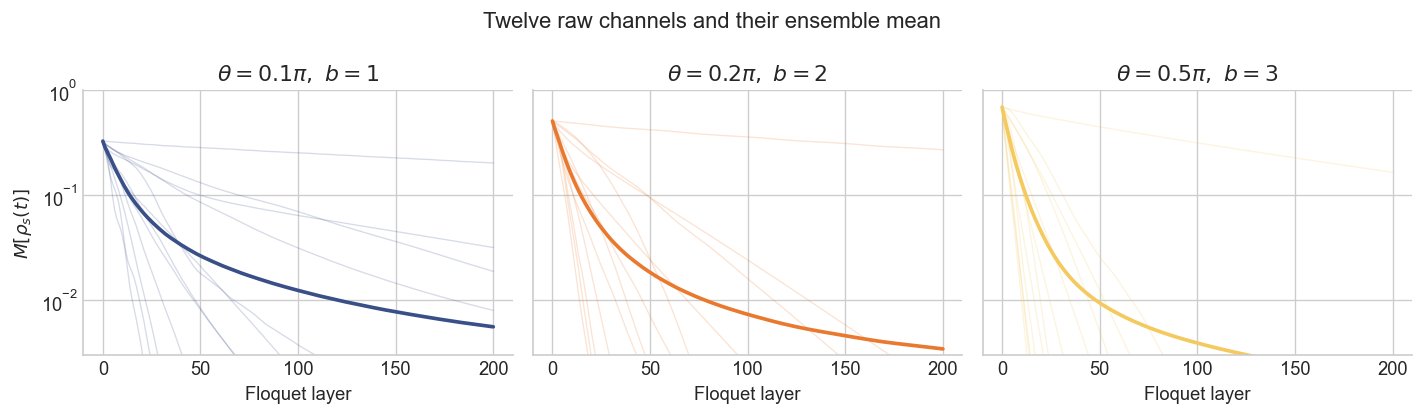

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for state_index, (ax, label, color) in enumerate(
    zip(axes, labels, PALETTE_3)
):
    for realization in range(12):
        ax.semilogy(
            times,
            np.maximum(
                asymmetry[realization, state_index], 1e-14
            ),
            color=color,
            alpha=0.20,
            lw=0.8,
        )
    ax.semilogy(
        times,
        np.maximum(
            asymmetry[:, state_index].mean(axis=0), 1e-14
        ),
        color=color,
        lw=2.2,
    )
    ax.set_ylim(3e-3, 1)
    ax.set(title=label, xlabel="Floquet layer")
axes[0].set_ylabel(r"$M[\rho_s(t)]$")
fig.suptitle("Twelve raw channels and their ensemble mean")
fig.tight_layout()
plt.show()


## 4. Ensemble reduction and Mpemba times

Bands use the 16th and 84th percentiles of the 100 raw values at
each time. A crossing time is linearly interpolated between the two
neighboring sampled layers.


In [6]:
mean_curves = asymmetry.mean(axis=0)
lower_curves, upper_curves = np.quantile(
    asymmetry, [0.16, 0.84], axis=0
)
mean_rates = data["slowest_log_modulus"].mean(axis=0)
std_rates = data["slowest_log_modulus"].std(axis=0)
mean_overlaps = data["slow_mode_overlap"].mean(axis=0)
std_overlaps = data["slow_mode_overlap"].std(axis=0)

for faster in (1, 2):
    tau = nu.crossing_time(
        times, mean_curves[faster], mean_curves[0]
    )
    print(
        f"{labels[faster]} crosses {labels[0]} at "
        f"t={tau:.2f}"
    )
    assert np.isfinite(tau)

assert np.all(np.diff(mean_rates) < 0)


$\theta=0.2\pi,\ b=2$ crosses $\theta=0.1\pi,\ b=1$ at t=16.97
$\theta=0.5\pi,\ b=3$ crosses $\theta=0.1\pi,\ b=1$ at t=9.98


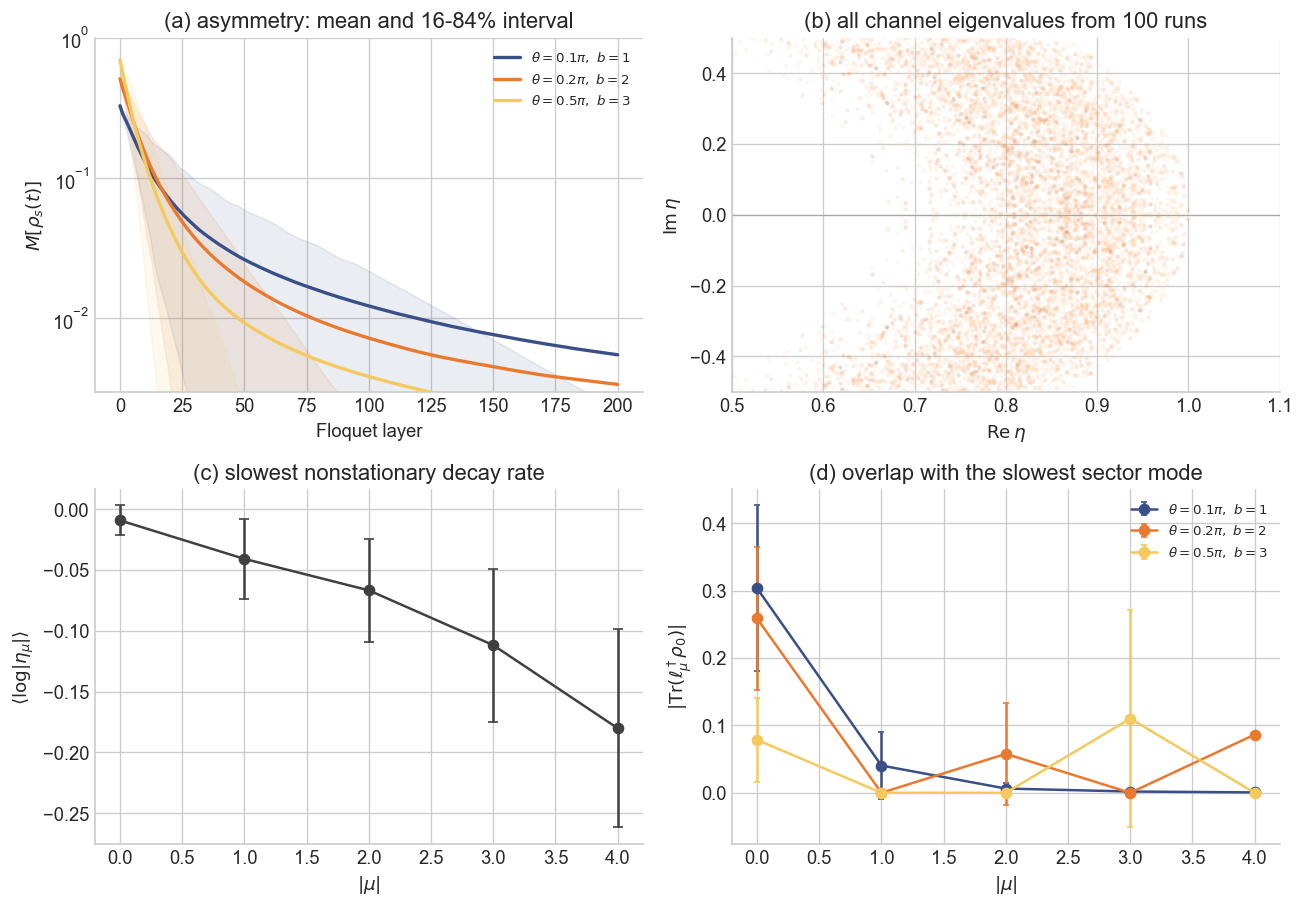

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.7))

for mean, lower, upper, label, color in zip(
    mean_curves,
    lower_curves,
    upper_curves,
    labels,
    PALETTE_3,
):
    axes[0, 0].semilogy(
        times, np.maximum(mean, 1e-14),
        color=color, lw=2, label=label
    )
    axes[0, 0].fill_between(
        times,
        np.maximum(lower, 1e-14),
        np.maximum(upper, 1e-14),
        color=color,
        alpha=0.1,
    )
axes[0, 0].set(
    xlabel="Floquet layer",
    ylabel=r"$M[\rho_s(t)]$",
    title="(a) asymmetry: mean and 16-84% interval",
)
axes[0, 0].set_ylim(3e-3, 1)
axes[0, 0].legend(fontsize=8)

spectrum = data["spectrum"]
spectrum_charge = data["spectrum_charge"]
for charge in range(-int(data["n_system"]),
                    int(data["n_system"]) + 1):
    values = spectrum[:, spectrum_charge == charge].ravel()
    axes[0, 1].scatter(
        values.real,
        values.imag,
        s=3,
        alpha=0.10,
        color=plt.cm.Oranges(
            abs(charge) / int(data["n_system"])
        ),
    )
axes[0, 1].set(
    xlabel=r"$\operatorname{Re}\eta$",
    ylabel=r"$\operatorname{Im}\eta$",
    title="(b) all channel eigenvalues from 100 runs",
)
axes[0, 1].set_ylim(-.5, .5)
axes[0, 1].set_xlim(.5, 1.1)
axes[0, 1].axhline(0, color="0.65", lw=0.7)

charges = np.arange(int(data["n_system"]) + 1)
axes[1, 0].errorbar(
    charges,
    mean_rates,
    yerr=std_rates,
    color="0.25",
    marker="o",
    capsize=3,
)
axes[1, 0].set(
    xlabel=r"$|\mu|$",
    ylabel=r"$\langle\log|\eta_\mu|\rangle$",
    title="(c) slowest nonstationary decay rate",
)

for state_index, (label, color) in enumerate(
    zip(labels, PALETTE_3)
):
    axes[1, 1].errorbar(
        charges,
        mean_overlaps[state_index],
        yerr=std_overlaps[state_index],
        color=color,
        marker="o",
        capsize=2,
        label=label,
    )
axes[1, 1].set(
    xlabel=r"$|\mu|$",
    ylabel=r"$|\operatorname{Tr}(\ell_\mu^\dagger\rho_0)|$",
    title="(d) overlap with the slowest sector mode",
)
axes[1, 1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Takeaway

The four panels are different views of the same simulated
ensemble. Block preparation removes entire low-charge sectors from
the initial state. Since the measured slow decay exponent becomes
more negative with $|\mu|$, the initially more asymmetric
high-block states overtake the $b=1$ state. No fitted or illustrative
curve enters this conclusion.
